# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [1]:

import pandas as pd
import numpy as np
emails = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")


corpus= emails["body"]
# corpus = emails["body"].dropna()
corpus

corpus = corpus.fillna("")

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**TYPE YOUR RESPONSE HERE.**
I would first make sure they are all lowercase, though I think they all already are. Then I would make sure that the all the missing values are dropped.

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
vec

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [3]:
vec.fit(corpus)
vocab = vec.get_feature_names_out()
vocab, len(vocab)

tf= vec.transform(corpus)


tf_df = pd.DataFrame(tf.toarray(), columns=vocab)
tf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


**TYPE YOUR RESPONSE HERE.**

Document frequency is the # of documents that contain a certain term divided by the total amount of documents. IDF is the inverse document frequency, which is the reciprocal of document frequency. TF-IDF could be more useful because it takes in the frequency of the word in the document, thus allowing us to better what words are more rare. 

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf = tfidf_vec.fit_transform(corpus)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns = tfidf_vec.get_feature_names_out())
tfidf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11587,0.0
1986,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1987,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1988,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


In [5]:
# Keep only the emails with a known spam label for this part

known = emails["spam"].notna()
spam = emails.loc[known, "spam"]

tf_known = tf_df[known]
tfidf_known = tfidf_df[known]
spam.value_counts()

spam
0.0    995
1.0    985
Name: count, dtype: int64

total_words        unique_words       
            mean median         mean median
spam                                       
0.0   135.327638   74.0    73.783920   54.0
1.0   176.189848   74.0   110.107614   64.0

Top terms for non-spam:


,TF,TF-IDF
0,the,the
1,to,ect
2,ect,to
3,and,enron
4,hou,hou
5,for,xls
6,enron,for
7,on,000
8,of,on
9,this,and


Top terms for spam:


,TF,TF-IDF
0,the,the
1,to,to
2,and,and
3,of,you
4,in,of
5,you,your
6,for,in
7,this,for
8,is,is
9,your,this


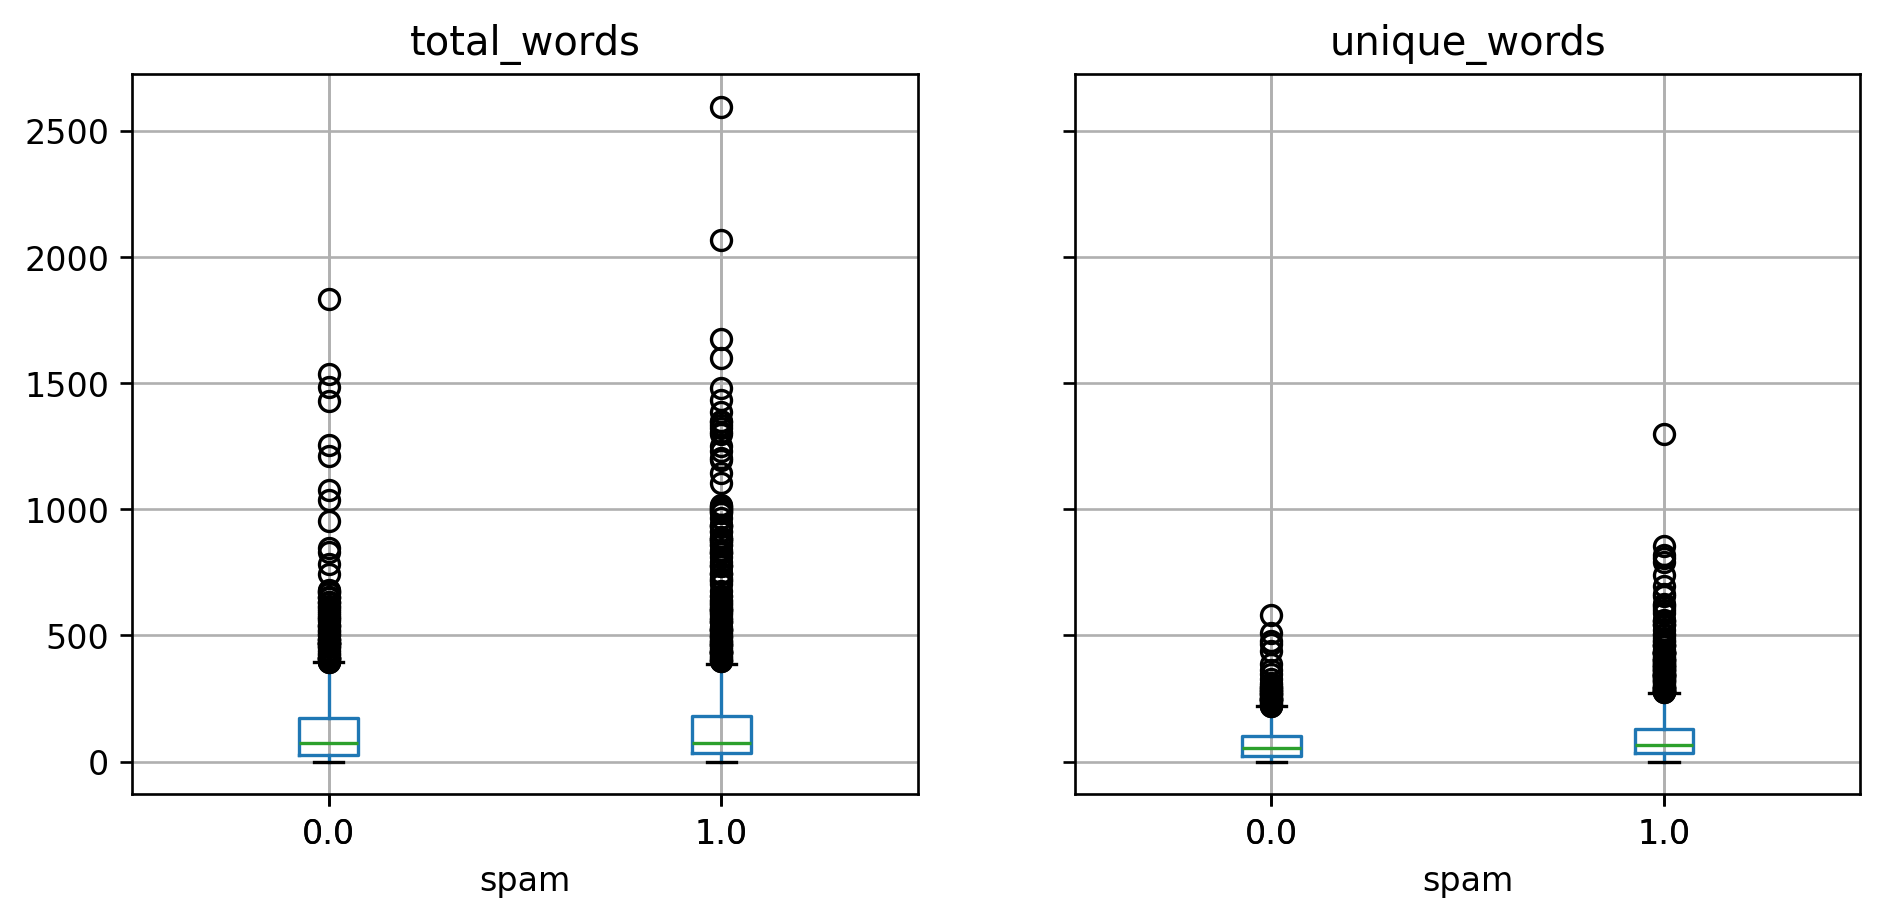

In [ ]:
import matplotlib.pyplot as plt


email_summary = pd.DataFrame({
    "spam": spam,
    "total_words": tf_known.sum(axis=1),
    "unique_words": (tf_known > 0).sum(axis=1)
})

display(email_summary.groupby("spam")[["total_words", "unique_words"]].agg(["mean", "median"]))

for label, name in [(0, "non-spam"), (1, "spam")]:
    top_tf = tf_known.loc[spam == label].mean().nlargest(10).index
    top_tfidf = tfidf_known.loc[spam == label].mean().nlargest(10).index
    print(f"Top terms for {name}:")
    display(pd.DataFrame({"TF": top_tf, "TF-IDF": top_tfidf}))

email_summary.boxplot(column=["total_words", "unique_words"], by="spam", figsize=(9, 4))
plt.suptitle("")
plt.show()

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**TYPE YOUR RESPONSE HERE.**
One simple method is to compare each unknown email with the known emails and find the ones whose word patterns are most similar. Cosine distance is useful because it compares the direction of the word-count vectors instead of being driven only by email length. For each unknown email, I could find its five nearest known neighbors and use their majority spam label as the guess. I would try both TF and TF-IDF; TF-IDF may work better because it reduces the influence of words that occur in nearly every email. This is essentially a simple nearest-neighbors classifier.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [7]:
from sklearn.metrics.pairwise import cosine_distances

email_index = 1980
tf_distances = cosine_distances(tf_df.loc[[email_index]], tf_known)[0]

tf_results = pd.DataFrame({
    "cosine_distance": tf_distances,
    "spam": spam.to_numpy()
}, index=tf_known.index)
tf_results.head()

,cosine_distance,spam
0,0.736928,0.0
1,0.542990,0.0
2,0.775802,0.0
3,0.653954,0.0
4,0.519088,0.0


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [8]:
tf_nearest = tf_results.sort_values("cosine_distance").head(10)
display(tf_nearest)

tf_votes = tf_nearest.head(5)["spam"].astype(int)
tf_guess = int(tf_votes.mode().iloc[0])
print(f"I would classify email 1980 as spam = {tf_guess} because its five nearest TF neighbors have labels {tf_votes.tolist()}.")

,cosine_distance,spam
1889,0.393060,1.0
1032,0.398488,1.0
1376,0.408606,1.0
714,0.414644,0.0
1110,0.415807,1.0
26,0.418573,0.0
180,0.423172,0.0
879,0.424620,0.0
713,0.427930,0.0
139,0.434841,0.0


I would classify email 1980 as spam = 1 because its five nearest TF neighbors have labels [1, 1, 1, 0, 1].


10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [9]:
tfidf_distances = cosine_distances(
    tfidf_df.loc[[email_index]], tfidf_known
)[0]

tfidf_results = pd.DataFrame({
    "cosine_distance": tfidf_distances,
    "spam": spam.to_numpy()
}, index=tfidf_known.index)

tfidf_nearest = tfidf_results.sort_values("cosine_distance").head(10)
display(tfidf_nearest)

tfidf_votes = tfidf_nearest.head(5)["spam"].astype(int)
tfidf_guess = int(tfidf_votes.mode().iloc[0])
print(f"The nearest emails and distances changed after using TF-IDF.")
print(f"The five TF-IDF neighbor labels are {tfidf_votes.tolist()}.")
print(f"The final guess did not change: TF guessed {tf_guess} and TF-IDF guessed {tfidf_guess}.")

,cosine_distance,spam
1032,0.755245,1.0
1977,0.780917,1.0
48,0.787975,0.0
1689,0.790205,1.0
1796,0.795094,1.0
180,0.797415,0.0
586,0.798537,0.0
1376,0.799377,1.0
279,0.799969,0.0
1021,0.801259,1.0


The nearest emails and distances changed after using TF-IDF.
The five TF-IDF neighbor labels are [1, 1, 0, 1, 1].
The final guess did not change: TF guessed 1 and TF-IDF guessed 1.


11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [10]:
# Guess each unknown email's label using its five nearest TF-IDF neighbors.
unknown_indices = emails.index[~known]
all_distances = cosine_distances(
    tfidf_df.loc[unknown_indices], tfidf_known
)

guesses = []
for row_number, email_index in enumerate(unknown_indices):
    nearest_positions = np.argsort(all_distances[row_number])[:5]
    nearest_labels = spam.iloc[nearest_positions]
    guess = int(nearest_labels.mean() >= 0.5)

    guesses.append({
        "email_index": email_index,
        "predicted_spam": guess,
        "neighbor_labels": nearest_labels.astype(int).tolist(),
        "closest_distance": all_distances[row_number, nearest_positions[0]]
    })

guesses_df = pd.DataFrame(guesses).set_index("email_index")
guesses_df

,predicted_spam,neighbor_labels,closest_distance
email_index,,,
1980,1,"[1, 1, 0, 1, 1]",0.755245
1981,0,"[0, 0, 0, 0, 0]",0.687836
1982,0,"[0, 1, 0, 0, 0]",0.614962
1983,0,"[0, 0, 0, 0, 0]",0.504036
1984,0,"[0, 0, 0, 0, 0]",0.389829
1985,1,"[1, 1, 1, 1, 0]",0.371277
1986,1,"[1, 1, 1, 1, 1]",0.768513
1987,1,"[1, 1, 1, 1, 1]",0.811616
1988,1,"[1, 1, 1, 1, 1]",0.748163
